# WM-811K Wafer Map Dataset — Exploration

**Goal of this project:** classify spatial defect signatures on wafer maps — the same task a defect systems engineer performs during excursion response, where the *shape* of the failing-die pattern (edge ring, scratch, center cluster…) points to a specific tool or process step.

**This notebook:** understand the dataset before modeling — how much of it is labeled, how imbalanced the classes are, what the maps actually look like, and what preprocessing the wafer geometry requires.

Dataset: [WM-811K / LSWMD](http://mirlab.org/dataSet/public/) — 811,457 wafer maps from 46,293 real production lots (Wu et al., IEEE TSM 2015).

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data

sns.set_theme(style="whitegrid")
df = data.load_raw()
print(f"{len(df):,} wafer maps from {df['lotName'].nunique():,} lots")
df.head(3)

811,457 wafer maps from 46,293 lots


,dieSize,failureType,lotName,trainTestLabel,waferIndex,waferMap,mapShape
0,1683.0,none,lot1,Training,1.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(45, 48)"
1,1683.0,none,lot1,Training,2.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(45, 48)"
2,1683.0,none,lot1,Training,3.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(45, 48)"


## 1. How much labeled data do we have?

Most maps in WM-811K carry no failure-type label — exactly like a real fab, where only a fraction of wafers ever get a reviewed disposition. We train on the labeled subset. Note the distinction: **"none" is itself a label** — an engineer's recorded judgment that the wafer shows no pattern. The ~638k unlabeled maps have no judgment recorded at all, and are not used anywhere in this project.

Labeled: 172,950 / 811,457 (21.3%)


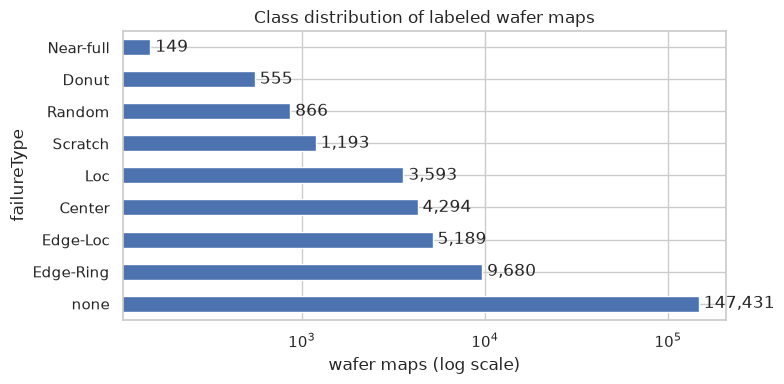

In [2]:
labeled = df[df["failureType"].notna()]
print(f"Labeled: {len(labeled):,} / {len(df):,} ({len(labeled)/len(df):.1%})")

counts = labeled["failureType"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
counts.plot.barh(ax=ax)
ax.set_xscale("log")
ax.set_xlabel("wafer maps (log scale)")
ax.set_title("Class distribution of labeled wafer maps")
for i, v in enumerate(counts):
    ax.text(v, i, f" {v:,}", va="center")
plt.tight_layout()
plt.savefig("../reports/figures/class_distribution.png", dpi=150)
plt.show()

The imbalance is severe — the majority of labeled wafers show **no** pattern, and the rarest classes (Near-full, Donut) have only a few dozen to few hundred examples. This drives two modeling decisions later:

1. Accuracy is a useless metric here — a model that always predicts "none" scores >85%. We evaluate **per-class recall** instead.
2. Training needs **class-balanced sampling** (or loss weighting) so rare-but-important patterns like Donut aren't ignored.

In fab terms: the rare classes are the ones that matter most — a Donut or Edge-Ring signature is actionable evidence of a specific failure mode, while "none" is just background.

## 2. What do the failure signatures look like?

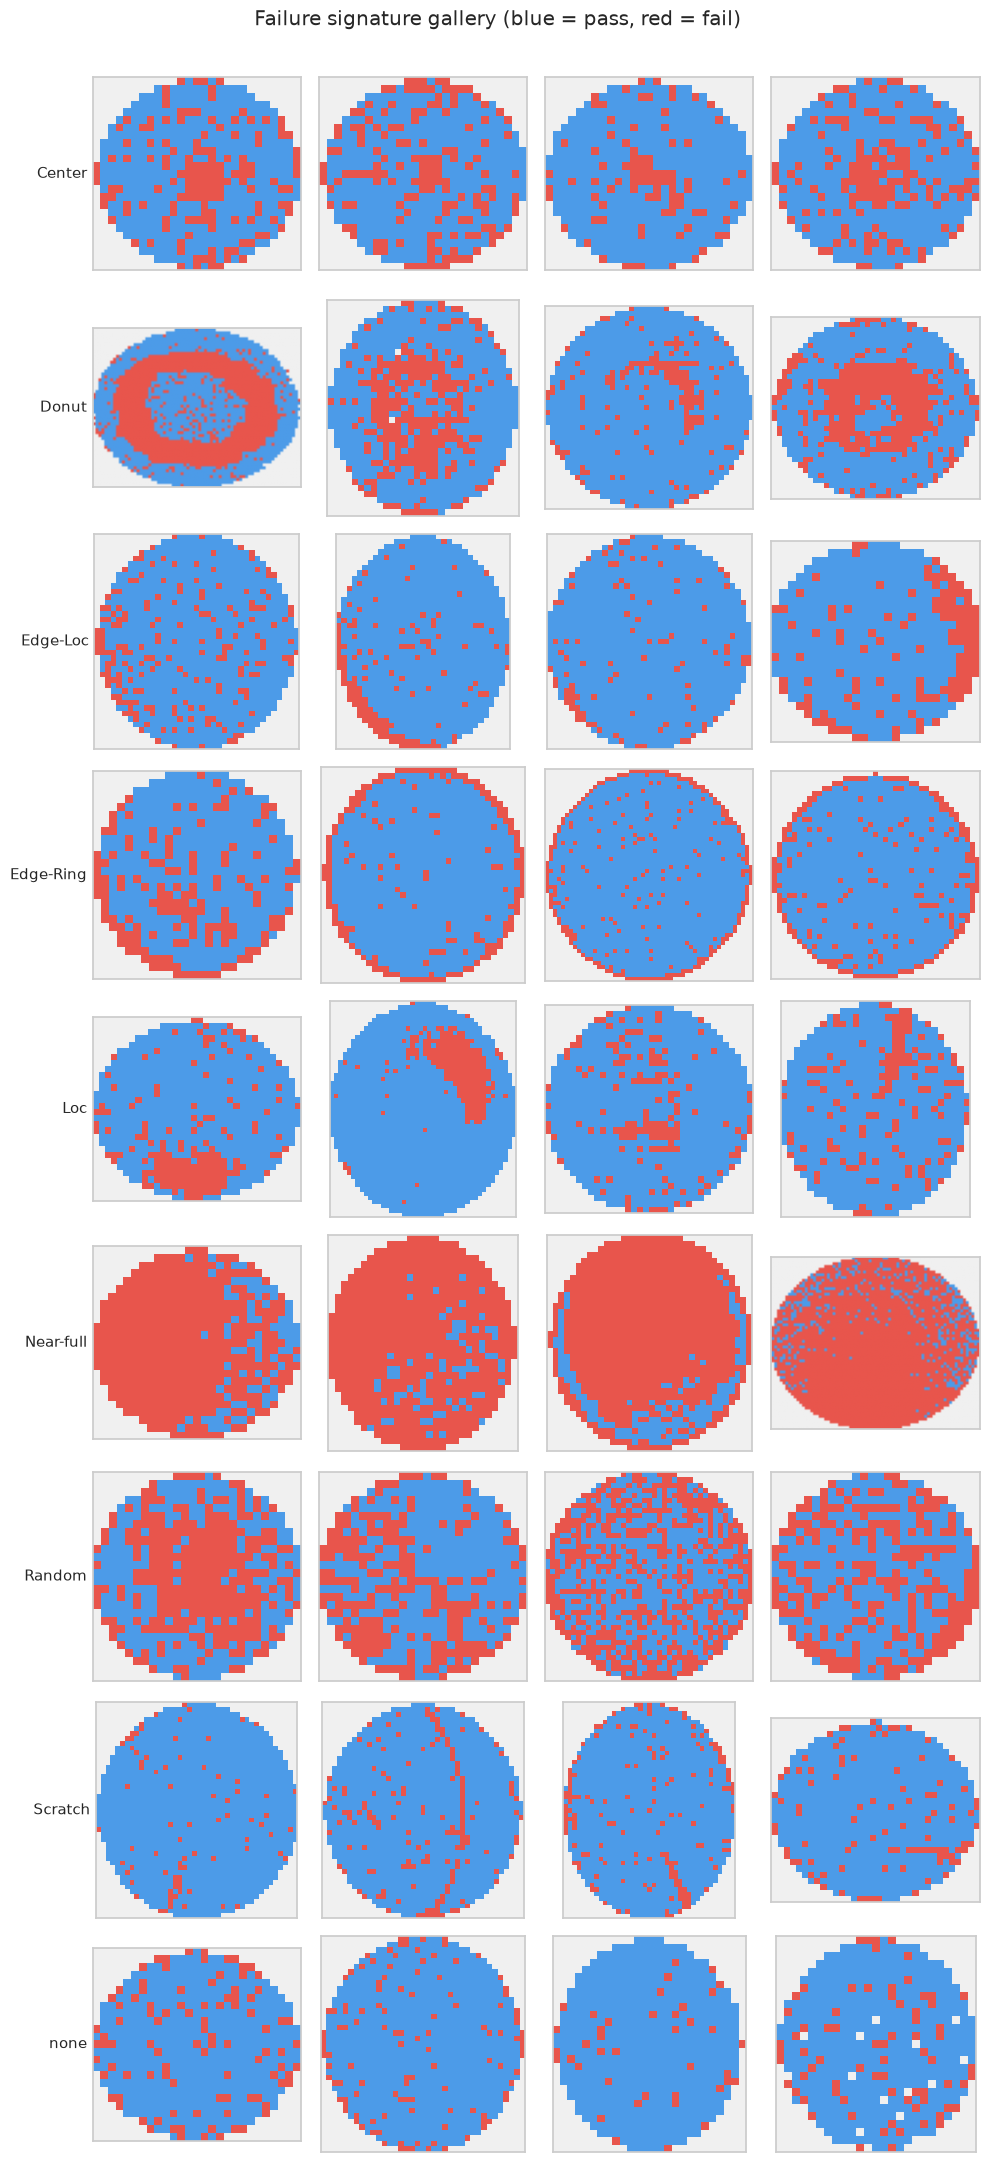

In [3]:
from matplotlib.colors import ListedColormap

# 0 = outside wafer, 1 = passing die, 2 = failing die
wafer_cmap = ListedColormap(["#f0f0f0", "#4c9be8", "#e8554c"])

classes = [c for c in data.CLASSES if c != "none"] + ["none"]
fig, axes = plt.subplots(len(classes), 4, figsize=(10, 2.4 * len(classes)))
rng = np.random.default_rng(0)
for row, cls in enumerate(classes):
    subset = labeled[labeled["failureType"] == cls]
    picks = subset.iloc[rng.choice(len(subset), size=4, replace=False)]
    for col, (_, wafer) in enumerate(picks.iterrows()):
        ax = axes[row, col]
        ax.imshow(wafer["waferMap"], cmap=wafer_cmap, vmin=0, vmax=2)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(cls, rotation=0, ha="right", va="center", fontsize=11)
fig.suptitle("Failure signature gallery (blue = pass, red = fail)", y=1.0)
plt.tight_layout()
plt.savefig("../reports/figures/signature_gallery.png", dpi=150, bbox_inches="tight")
plt.show()

Each signature has a physical story — this is why the classification is worth automating:

| Signature | Typical fab root-cause direction |
|---|---|
| Center | Chamber center non-uniformity, dispense/spin issues |
| Donut | Ring-shaped process non-uniformity (e.g. edge/center etch rate delta) |
| Edge-Loc / Edge-Ring | Edge exclusion, clamp/chuck contact, bevel processes |
| Loc | Localized cluster — particles, single-point tool contact |
| Scratch | Wafer handling / transfer damage |
| Near-full | Gross process failure — wrong recipe, skipped step |
| Random | Baseline defectivity, no single assignable cause |

## 3. Wafer geometry varies — maps need normalization

In [4]:
shapes = labeled["mapShape"].value_counts()
print(f"{len(shapes)} distinct map shapes among labeled wafers. Top 10:")
print(shapes.head(10))
dims = np.array(labeled["mapShape"].tolist())
print(f"\nRows: {dims[:,0].min()}–{dims[:,0].max()}, Cols: {dims[:,1].min()}–{dims[:,1].max()}")

346 distinct map shapes among labeled wafers. Top 10:
mapShape
(25, 27)    18781
(26, 26)    14366
(30, 34)    12400
(29, 26)    11751
(27, 25)    10682
(39, 37)    10173
(33, 29)     8125
(42, 44)     6724
(44, 41)     6134
(41, 33)     5091
Name: count, dtype: int64

Rows: 15–212, Cols: 3–204


Maps come in many die-grid sizes (different products / die sizes), so both the feature pipeline and the CNN operate on maps resampled to a fixed **64×64** grid with nearest-neighbour interpolation, which preserves the discrete {outside, pass, fail} encoding.

## Next

- `02_baseline.ipynb` — hand-crafted features (radial densities, radon projections, region geometry) + gradient boosting
- `03_supervised_cnn.ipynb` — convolutional network on the normalized maps, class-balanced training